In [1]:
from script import test_function
import matplotlib.pyplot as plt
import numpy as np

In [2]:
n = 100
m = 25
max_number_oracle_calls = n * 1000
alpha_bar_dual_sub = 10
alpha_bar_two_stage = 1
sc_problem, history_dual_sub, history_stoch_dual_sub, history_block_FW, X, X_sol = test_function(n, m, max_number_oracle_calls, 
                                                                                                 alpha_bar_dual_sub=alpha_bar_dual_sub,
                                                                                                 alpha_bar_two_stage=alpha_bar_two_stage)

Approximate value of G = 269.4941904751679
At iteration 0, dual value = -247.74146901093272
   Primal value = -249.684583957041, infeasibility = 163.24513751411124
At iteration 10, dual value = -172.02325230109054
   Primal value = -114.83080512073454, infeasibility = 7.371931882960986
At iteration 20, dual value = -152.76698904503849
   Primal value = -125.48787138155845, infeasibility = 4.556167189676334
At iteration 30, dual value = -146.55768803953634
   Primal value = -130.3947067774873, infeasibility = 3.203915293272624
At iteration 40, dual value = -144.3012983889457
   Primal value = -132.89830738680917, infeasibility = 2.4361034261776187
At iteration 50, dual value = -143.22343087521156
   Primal value = -134.4362540769921, infeasibility = 1.9596010510861221
At iteration 60, dual value = -142.61282349302388
   Primal value = -135.49069049465817, infeasibility = 1.6430393422657896
At iteration 70, dual value = -142.21142170772345
   Primal value = -136.2769263537541, infeasibil

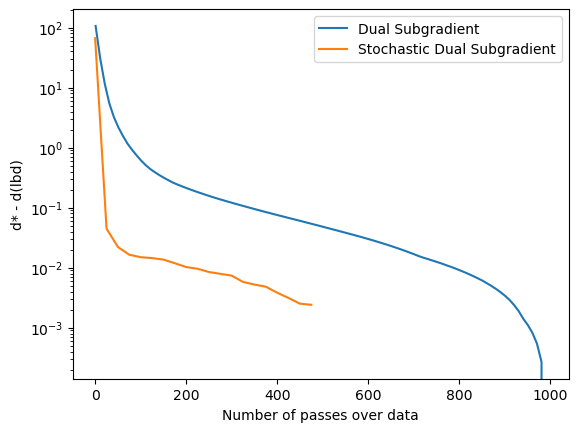

In [4]:
best_dual_value = np.maximum(np.max(history_dual_sub['dual_value']), np.max(history_stoch_dual_sub['dual_value']))

plt.plot(np.array(history_dual_sub['nb_oracle_calls'])/n, best_dual_value - np.array(history_dual_sub['dual_value']), label="Dual Subgradient")
plt.plot(np.array(history_stoch_dual_sub['nb_oracle_calls'])/n, best_dual_value - np.array(history_stoch_dual_sub['dual_value']), label="Stochastic Dual Subgradient")


plt.xlabel('Number of passes over data')
plt.ylabel('d* - d(lbd)')
plt.yscale('log')
plt.legend()

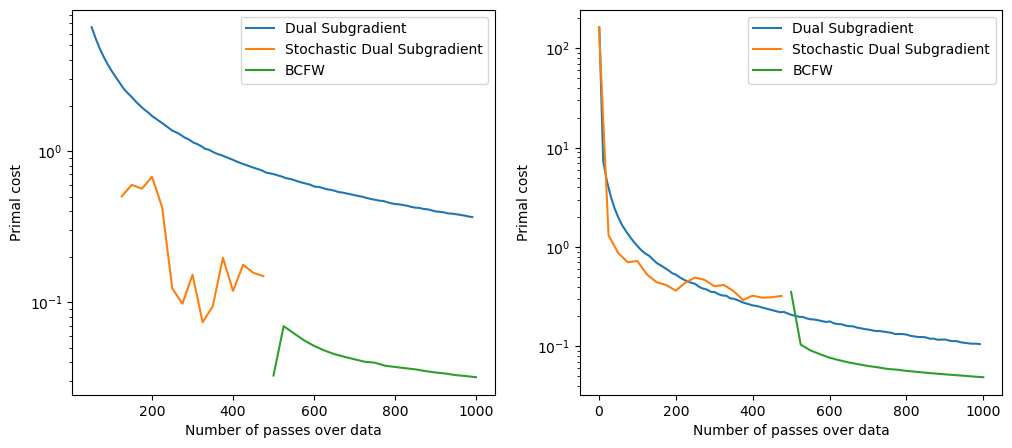

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

first_index = 5
ax1.plot(np.array(history_dual_sub['nb_oracle_calls'])[first_index:]/n, history_dual_sub['primal_value'][first_index:] - best_dual_value, label="Dual Subgradient")
ax1.plot(np.array(history_stoch_dual_sub['nb_oracle_calls'])[first_index:]/n, history_stoch_dual_sub['primal_value'][first_index:] - best_dual_value, label="Stochastic Dual Subgradient")
ax1.plot(np.array(history_block_FW['nb_oracle_calls'])/n, history_block_FW['primal_value'] - best_dual_value, label="BCFW")


ax1.set_xlabel('Number of passes over data')
ax1.set_ylabel('Primal cost')
ax1.set_yscale('log')
ax1.legend()

ax2.plot(np.array(history_dual_sub['nb_oracle_calls'])/n, history_dual_sub['infeasibility'], label="Dual Subgradient")
ax2.plot(np.array(history_stoch_dual_sub['nb_oracle_calls'])/n, history_stoch_dual_sub['infeasibility'], label="Stochastic Dual Subgradient")
ax2.plot(np.array(history_block_FW['nb_oracle_calls'])/n, history_block_FW['infeasibility'], label="BCFW")


ax2.set_xlabel('Number of passes over data')
ax2.set_ylabel('Primal cost')
ax2.set_yscale('log')
ax2.legend()